# 08 — LR vs RF Comparison

Side-by-side comparison of baseline LR (56K genes) vs RF (20K variance-filtered).

In [1]:
import pandas as pd
from gtex_biomarkers.config import Config
from gtex_biomarkers.utils import build_comparison_table
from gtex_biomarkers.evaluation import plot_comparison_scatter, plot_comparison_barplot

Config.ensure_dirs()

lr_summary = pd.read_csv(Config.TABLES_DIR / "cv_results_all_tissue_pathology.csv")
rf_summary = pd.read_csv(Config.TABLES_DIR / "cv_results_all_tissue_rf.csv")

## Comparison Table

In [2]:
comp = build_comparison_table(lr_summary, rf_summary)
print(f"RF better: {(comp['auc_diff'] > 0).sum()}")
print(f"LR better: {(comp['auc_diff'] < 0).sum()}")
print(f"Mean improvement: {comp['auc_diff'].mean():.4f}")
comp.to_csv(Config.TABLES_DIR / "comparison_lr_vs_rf.csv", index=False)
display(comp[["tissue", "category", "mean_auc_lr", "mean_auc_rf", "auc_diff"]])

RF better: 36
LR better: 17
Mean improvement: 0.0263


,tissue,category,mean_auc_lr,mean_auc_rf,auc_diff
46,Prostate,hyperplasia,0.349217,0.549267,0.200050
13,Artery - Tibial,monckeberg,0.483571,0.646771,0.163199
43,Ovary,post_menopausal,0.464706,0.585107,0.120401
24,Kidney - Cortex,fibrosis,0.493939,0.605070,0.111131
5,Artery - Aorta,sclerotic,0.500467,0.605494,0.105027
29,Liver,fibrosis,0.380177,0.481555,0.101378
2,Artery - Aorta,atherosclerosis,0.462177,0.559494,0.097317
48,Testis,spermatogenesis,0.616459,0.711798,0.095339
28,Liver,congestion,0.590135,0.683426,0.093290
15,Breast - Mammary Tissue,atrophy,0.756261,0.841520,0.085258


## Scatter Plot

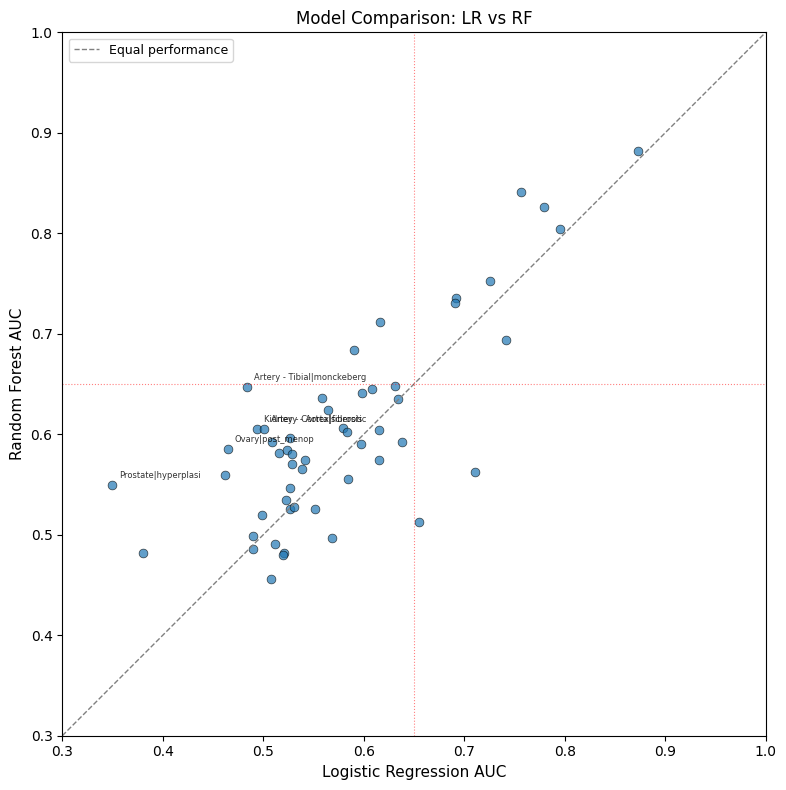

In [3]:
plot_comparison_scatter(comp,
                        save_path=Config.FIGURES_DIR / "comparison_scatter_lr_vs_rf.pdf")

## AUC Difference Bar Chart

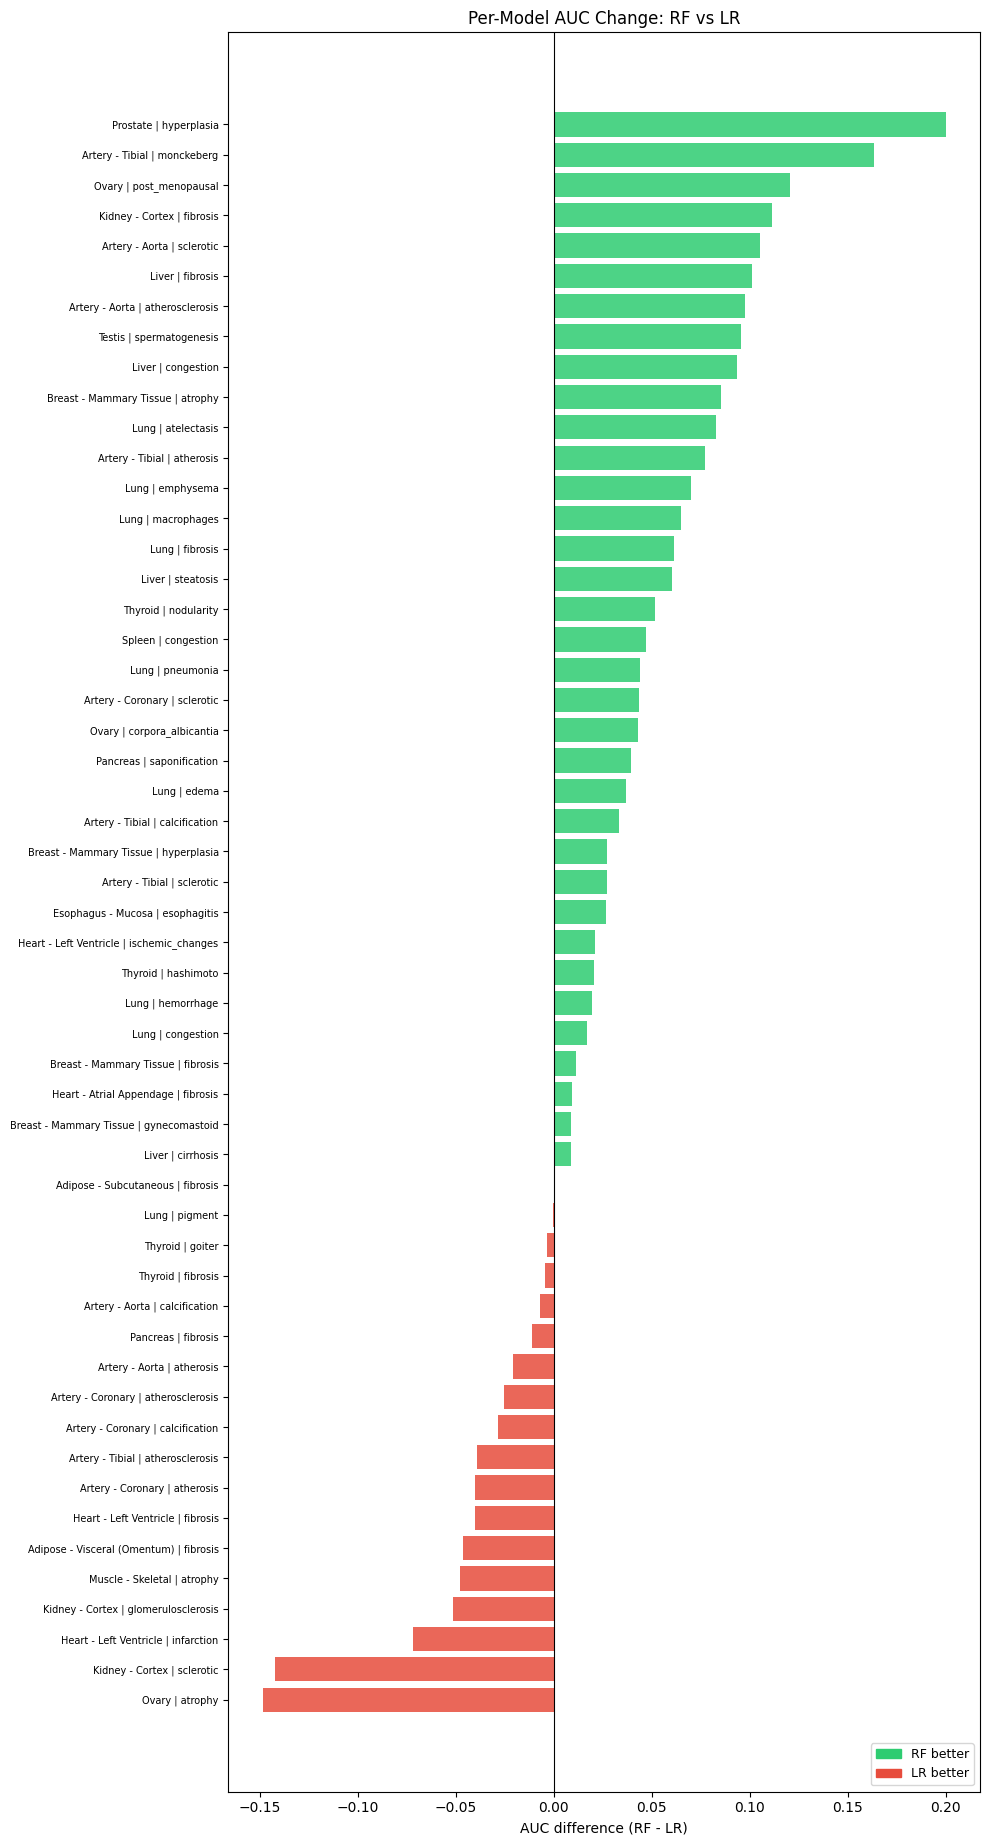

In [4]:
plot_comparison_barplot(comp,
                        save_path=Config.FIGURES_DIR / "comparison_barplot_auc_diff.pdf")